# Warehouse Routing Algorithm Evaluation

This notebook is the visible evaluator evidence for the OptiWMS worker-routing
control plane. It uses the controlled v8 physical population, compares
Dijkstra and A*, and stress-tests independent versus time-reservation A* for
1, 5, 10, 25 and 50 concurrent forklifts.

**Decision boundary:** this validates the implemented method on synthetic
geometry. It does not certify real-site safety. A physical survey, positioning
telemetry, vehicle envelopes, right-of-way rules and shadow-mode acceptance
remain mandatory.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

HERE = Path.cwd()
if HERE.name != "warehouse_routing_evaluation":
    HERE = Path("Ai miroservices/modeling/warehouse_routing_evaluation").resolve()
OUT = HERE / "outputs"
leaderboard = pd.read_csv(OUT / "algorithm_leaderboard.csv")
cases = pd.read_csv(OUT / "static_route_cases.csv")
concurrency = pd.read_csv(OUT / "concurrency_results.csv")
tests = pd.read_csv(OUT / "statistical_tests.csv")
assumptions = pd.read_csv(OUT / "assumption_registry.csv")
claims = pd.read_csv(OUT / "claim_evidence_matrix.csv")
decision = json.loads((OUT / "routing_algorithm_decision.json").read_text())
decision

{'dataset': '/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling/v8_controlled_synthetic_validation/outputs/physical_layout.csv.gz',
 'seed': 20260728,
 'graph': {'nodes': 956,
  'directed_edges': 1980,
  'rack_bays': 280,
  'mapped_locations': 4200},
 'selection': {'single_agent_shortest_path': 'astar',
  'multi_agent_control': 'reservation_astar',
  'reason': 'A* preserves Dijkstra-optimal distance while reducing search; time-aware reservations eliminate tested node/edge-time conflicts.'},
 'acceptance': {'all_static_distances_match': True,
  'zero_reserved_conflicts': True,
  'tested_max_workers': 50,
  'external_population_validity': 'UNVERIFIED',
  'safety_certification': 'NOT_CLAIMED'}}

## 1. Versioned graph and population contract

In [2]:
graph_summary = pd.DataFrame([decision["graph"]])
graph_summary["layout_source"] = "v8 controlled physical population"
graph_summary["external_population_validity"] = decision["acceptance"]["external_population_validity"]
display(graph_summary)

,nodes,directed_edges,rack_bays,mapped_locations,layout_source,external_population_validity
0,956,1980,280,4200,v8 controlled physical population,UNVERIFIED


The 4,200 storage-bin records are not drawn as 4,200 floor obstacles. They
collapse to 280 rack-bay footprints with two valid rack-face approaches. The
route graph contains aisle and cross-aisle centerlines, station links and
parking nodes, so generated polylines cannot cross a rack footprint.

## 2. Static shortest-path comparison

In [3]:
display(leaderboard.round(4))

,algorithm,cases,median_runtime_ms,p95_runtime_ms,median_expanded_nodes,distance_match_rate
0,astar,160,0.2050,0.6794,181.0,1.0
1,dijkstra,160,0.3514,0.6596,485.5,1.0


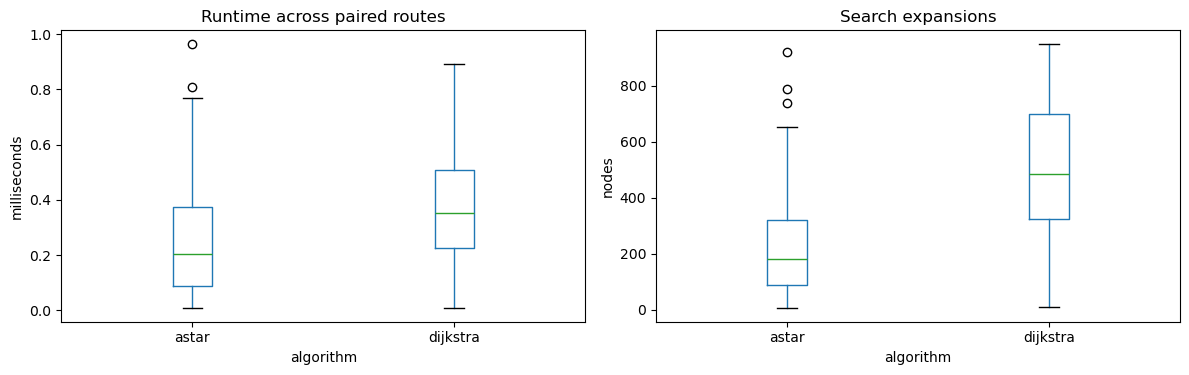

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cases.boxplot(column="runtime_ms", by="algorithm", ax=axes[0], grid=False)
axes[0].set_title("Runtime across paired routes")
axes[0].set_ylabel("milliseconds")
cases.boxplot(column="expanded_nodes", by="algorithm", ax=axes[1], grid=False)
axes[1].set_title("Search expansions")
axes[1].set_ylabel("nodes")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [5]:
display(tests)

,claim,effect_mean,ci95_low,ci95_high,p_value,test,supported
0,A* reduces wall-clock runtime versus Dijkstra,0.095926,0.073703,0.118929,1.761067e-15,paired Wilcoxon + paired bootstrap,True
1,A* reduces node expansions versus Dijkstra,265.231250,237.312031,293.923281,0.000000e+00,paired bootstrap,True


A* is selected for single-agent route geometry because its Manhattan heuristic
is admissible on this orthogonal, nonnegative graph. Dijkstra remains the
optimality reference. Distance equivalence is required; runtime alone is not
enough.

## 3. Multi-worker temporal conflict evidence

In [6]:
concurrency_summary = (
    concurrency.groupby(["workers", "algorithm"])
    .agg(
        max_temporal_conflicts=("temporal_conflicts", "max"),
        mean_total_wait_seconds=("total_wait_seconds", "mean"),
        mean_p95_runtime_ms=("p95_runtime_ms", "mean"),
        mean_makespan_seconds=("makespan_seconds", "mean"),
    )
    .reset_index()
)
display(concurrency_summary.round(3))

,workers,algorithm,max_temporal_conflicts,mean_total_wait_seconds,mean_p95_runtime_ms,mean_makespan_seconds
0,1,independent_astar,0,0.000,0.235,95.583
1,1,reservation_astar,0,0.000,0.362,95.583
2,5,independent_astar,365,0.000,0.389,163.083
3,5,reservation_astar,0,36.167,0.617,170.333
4,10,independent_astar,1076,0.000,0.584,188.833
5,10,reservation_astar,0,194.917,1.006,221.375
6,25,independent_astar,6768,0.000,0.621,195.417
7,25,reservation_astar,0,1383.625,1.125,281.833
8,50,independent_astar,32988,0.000,0.601,200.167
9,50,reservation_astar,0,5845.333,1.106,431.292


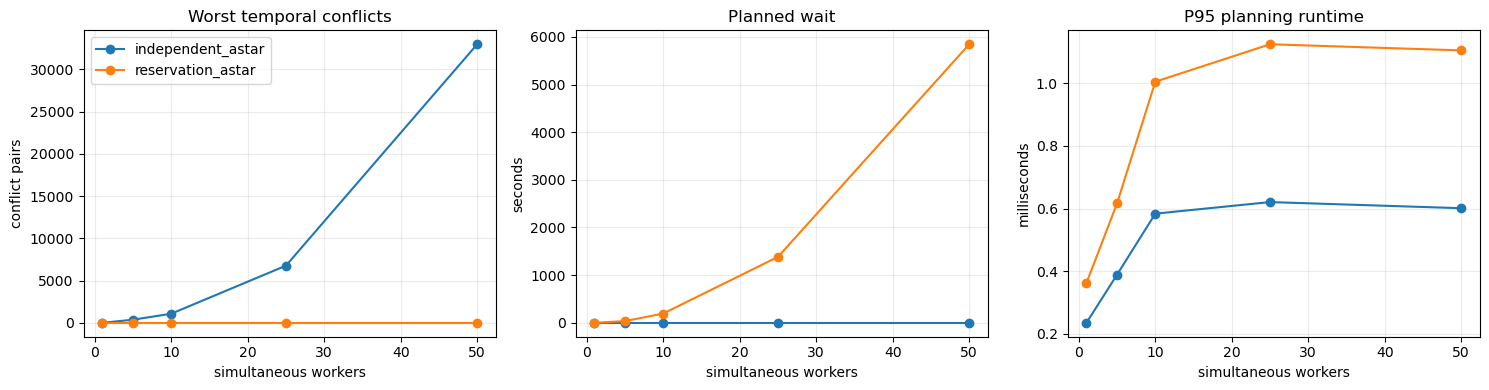

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for algorithm, frame in concurrency_summary.groupby("algorithm"):
    axes[0].plot(frame.workers, frame.max_temporal_conflicts, marker="o", label=algorithm)
    axes[1].plot(frame.workers, frame.mean_total_wait_seconds, marker="o", label=algorithm)
    axes[2].plot(frame.workers, frame.mean_p95_runtime_ms, marker="o", label=algorithm)
axes[0].set_title("Worst temporal conflicts")
axes[1].set_title("Planned wait")
axes[2].set_title("P95 planning runtime")
for axis in axes:
    axis.set_xlabel("simultaneous workers")
    axis.grid(alpha=.25)
axes[0].set_ylabel("conflict pairs")
axes[1].set_ylabel("seconds")
axes[2].set_ylabel("milliseconds")
axes[0].legend()
plt.tight_layout()
plt.show()

Independent A* is rejected for multi-forklift control: geometrically shortest
routes overlap in time. The production design therefore uses server-side
prioritized reservation A*, canonical undirected edge resources (which also
block opposite-direction swaps), destination-node windows, safety headway,
leases and replanning after completed stops.

## 4. Assumption registry

In [8]:
display(assumptions)

,assumption,status,evidence,operational_response
0,The v8 coordinate population maps every synthe...,SUPPORTED,4200 mapped positions across 280 rack bays,Use only active dataset-version mappings
1,The generated graph is connected from operatin...,SUPPORTED,160 deterministic origin-destination cases wer...,Reject graph activation when a required route ...
2,A* requires Gaussian runtimes or residuals,NOT_REQUIRED,Paired bootstrap and Wilcoxon inference are di...,Retain non-parametric inference
3,Constant 1.5 m/s travel speed represents actua...,UNVERIFIED,Configured simulation value; no site telemetry...,Calibrate by vehicle/load/zone before producti...
4,Synthetic aisle widths and rack dimensions mat...,UNVERIFIED,v8 controlled layout contract only,"Survey clear widths, rack envelopes and one-wa..."
5,Prioritized reservations cannot starve lower-p...,UNVERIFIED,No starvation in bounded scenarios; no long-ru...,Add aging/priority policy and alert on excessi...
6,Reservation-aware routes are conflict-free in ...,SUPPORTED,Zero node/edge-time conflicts through 50 simul...,"Keep server authority, leases, version checks ..."
7,Synthetic benchmark performance generalizes to...,UNVERIFIED,No representative indoor-positioning or travel...,Run shadow mode and site acceptance; do not cl...


## 5. Claim–evidence matrix

In [9]:
display(claims)

,claim,artifact,result,status
0,A* returns shortest paths on the active nonneg...,static_route_cases.csv,All A* distances matched Dijkstra,SUPPORTED
1,A* is the appropriate single-route search,algorithm_leaderboard.csv; statistical_tests.csv,Lower median runtime and expansions with paire...,SUPPORTED
2,Independent A* is sufficient for multiple fork...,concurrency_results.csv,Temporal conflicts appear from 5 workers,REJECTED
3,Reservation A* prevents tested edge/node time ...,concurrency_results.csv,Zero detected conflicts for every tested batch...,SUPPORTED
4,The system is certified safe for a real forkli...,assumption_registry.csv,"Physical measurements, telemetry and shadow ac...",REJECTED


## 6. Locked conclusion

In [10]:
assert decision["acceptance"]["all_static_distances_match"]
assert decision["acceptance"]["zero_reserved_conflicts"]
assert decision["acceptance"]["tested_max_workers"] == 50
assert decision["acceptance"]["external_population_validity"] == "UNVERIFIED"
pd.DataFrame([
    {"use": "Single worker geometry", "selected": "A*"},
    {"use": "Concurrent operational control", "selected": "time-reservation A*"},
    {"use": "Real-site safety certification", "selected": "NOT ESTABLISHED"},
])

,use,selected
0,Single worker geometry,A*
1,Concurrent operational control,time-reservation A*
2,Real-site safety certification,NOT ESTABLISHED
